# 07 · Comparativa de modelos

**Proyecto Final — Machine Learning y Deep Learning**

### Qué hace este notebook
**Entrenar** un modelo es mostrarle muchos ejemplos para que aprenda los patrones. Aquí **no entrenamos de nuevo**: cargamos los modelos que ya entrenó el proceso principal (`python -m src.train`), los **evaluamos** sobre datos que no vieron y los **comparamos** para elegir el mejor.

Comparamos cinco modelos de familias distintas (todos explicados en `docs/glosario.md`):
1. **Regresión logística** — modelo lineal sencillo (línea base).
2. **Árbol de decisión** — preguntas tipo sí/no encadenadas.
3. **Random Forest** — muchos árboles que votan (*ensemble*).
4. **XGBoost** — árboles que corrigen los errores de los anteriores (*boosting*).
5. **Red neuronal (Keras)** — capas de neuronas (*deep learning*).

> ⚠️ **Requisito:** ejecutar antes `python -m src.train` desde la raíz del repo para generar `models/*.pkl` (los modelos guardados) y `outputs/*.png` (los gráficos).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')  # silencia mensajes de TensorFlow

import warnings; warnings.filterwarnings('ignore')
import joblib, re                       # joblib: cargar modelos guardados (.pkl)
import pandas as pd
from IPython.display import Image, display

from src import config
from src.data_loader import load_and_prepare
from src.evaluator import Evaluator


## 1. Cargar los modelos entrenados y los datos de prueba

Reconstruimos la **misma división** train/test que usó el entrenamiento (gracias a la semilla fija `random_state = 42`, sale idéntica) y cargamos los cinco modelos guardados en disco. Cada modelo es un **Pipeline**: lleva dentro el preprocesado + el algoritmo, así que recibe los datos en crudo.

In [2]:
X_train, X_test, y_train, y_test = load_and_prepare()
print('Reservas para prueba (test):', len(X_test))

nombres = ['Logistic Regression', 'Decision Tree', 'Random Forest',
           'XGBoost', 'Neural Network (Keras)']
modelos = {}
for nombre in nombres:
    slug = re.sub(r'[^a-z0-9]+', '_', nombre.lower()).strip('_')
    modelos[nombre] = joblib.load(config.MODELS_DIR / f'{slug}.pkl')
print('Modelos cargados:', list(modelos))

Reservas para prueba (test): 23842


Modelos cargados: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network (Keras)']


## 2. Evaluación y tabla comparativa

Usamos la clase `Evaluator` (la misma del proceso principal) para calcular las métricas sobre el conjunto de prueba. Breve recordatorio (detalle en el glosario):

- **accuracy** (exactitud): % de aciertos totales.
- **precision** (precisión): de las que predije "cancela", cuántas lo eran.
- **recall** (sensibilidad): de las cancelaciones reales, cuántas detecté.
- **F1**: equilibrio entre precision y recall.
- **ROC-AUC**: capacidad de **ordenar** bien por riesgo (0.5 = azar, 1 = perfecto).

In [3]:
evaluator = Evaluator()
evaluator.evaluate(modelos, X_test, y_test)
tabla = evaluator.comparison_table()
# La tabla se ordena por la métrica principal; coloreamos para leerla mejor.
tabla.style.background_gradient(cmap='Greens', subset=config.METRIC_NAMES).format('{:.4f}')

,accuracy,precision,recall,f1,roc_auc
XGBoost,0.8925,0.8680,0.8376,0.8525,0.9603
Neural Network (Keras),0.8746,0.8502,0.8034,0.8262,0.9483
Random Forest,0.8680,0.8852,0.7399,0.8061,0.9482
Decision Tree,0.8588,0.8344,0.7725,0.8023,0.9369
Logistic Regression,0.8211,0.7333,0.8132,0.7712,0.9077


### ¿Por qué ROC-AUC como métrica principal?

1. **Robusta al desbalance** (~37 % de cancelaciones): no se deja engañar por la clase mayoritaria, como sí le pasa a la *accuracy*.
2. **No depende del umbral**: mide la capacidad de **ordenar** las reservas por riesgo. El *umbral* (el corte para decidir "cancela/no cancela", por defecto 0.5) puede ajustarse después según la política de *overbooking* del hotel.
3. **Comparable** entre algoritmos muy distintos.

Como métricas secundarias de negocio miramos **recall** (cancelaciones detectadas) y **F1** (equilibrio).

In [4]:
mejor = evaluator.select_best()
print('Mejor modelo según', config.PRIMARY_METRIC, '->', mejor)
tabla.loc[[mejor]]

Mejor modelo según roc_auc -> XGBoost


,accuracy,precision,recall,f1,roc_auc
XGBoost,0.892543,0.867995,0.837557,0.852504,0.960314


## 3. Curva ROC comparativa

La **curva ROC** muestra, para cada modelo, el equilibrio entre **detectar cancelaciones** (eje Y, *TPR*) y **dar falsas alarmas** (eje X, *FPR*) según el umbral. Cuanto más se acerca la curva a la **esquina superior izquierda**, mejor. El **AUC** (área bajo la curva) resume cada curva en un número.

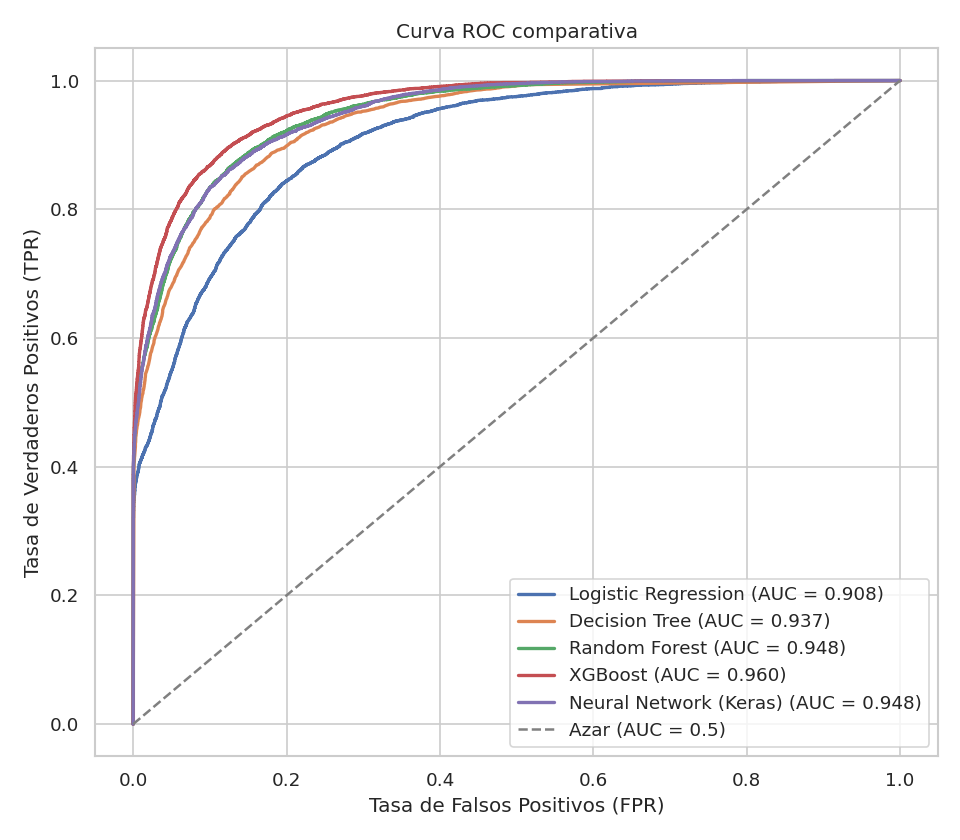

In [5]:
display(Image(filename=str(config.OUTPUTS_DIR / 'roc_curves.png')))

## 4. Matrices de confusión

La **matriz de confusión** cruza lo que el modelo **predijo** con lo que **realmente pasó**. Los **aciertos** están en la diagonal; fuera de ella, los errores: *falsos positivos* (falsa alarma) y *falsos negativos* (cancelación que se nos escapó).

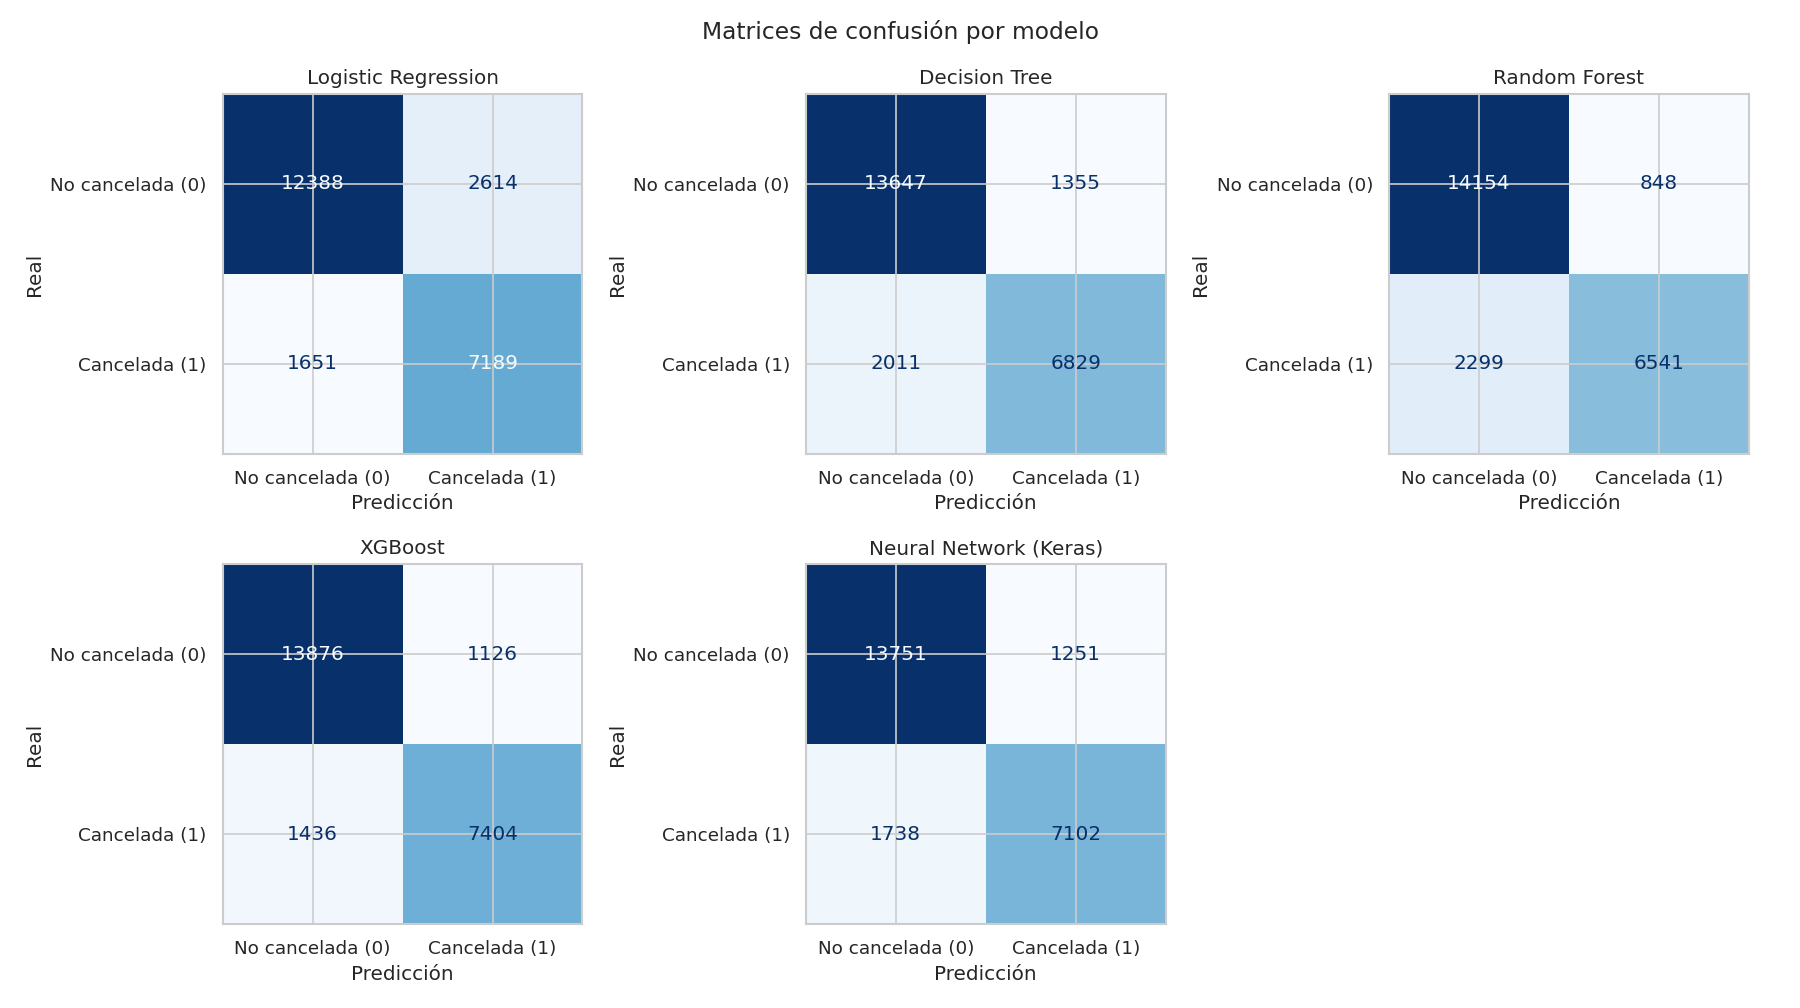

In [6]:
display(Image(filename=str(config.OUTPUTS_DIR / 'confusion_matrices.png')))

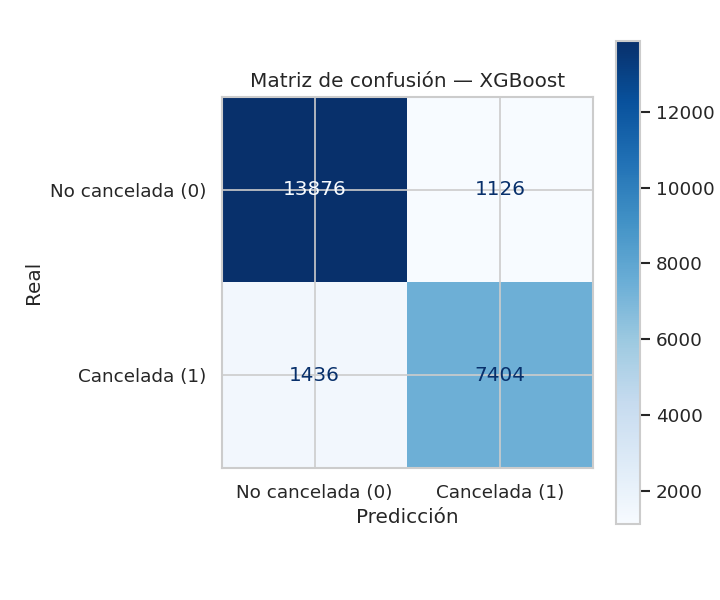

In [7]:
# Matriz de confusión solo del mejor modelo, con etiquetas claras
display(Image(filename=str(config.OUTPUTS_DIR / 'confusion_matrix_best.png')))

## 5. Importancia de variables (Random Forest)

La **importancia de variables** (*feature importances*) indica **cuánto influye cada característica** en las decisiones del modelo. Ayuda a *interpretar* el modelo: ver si "razona" con sentido.

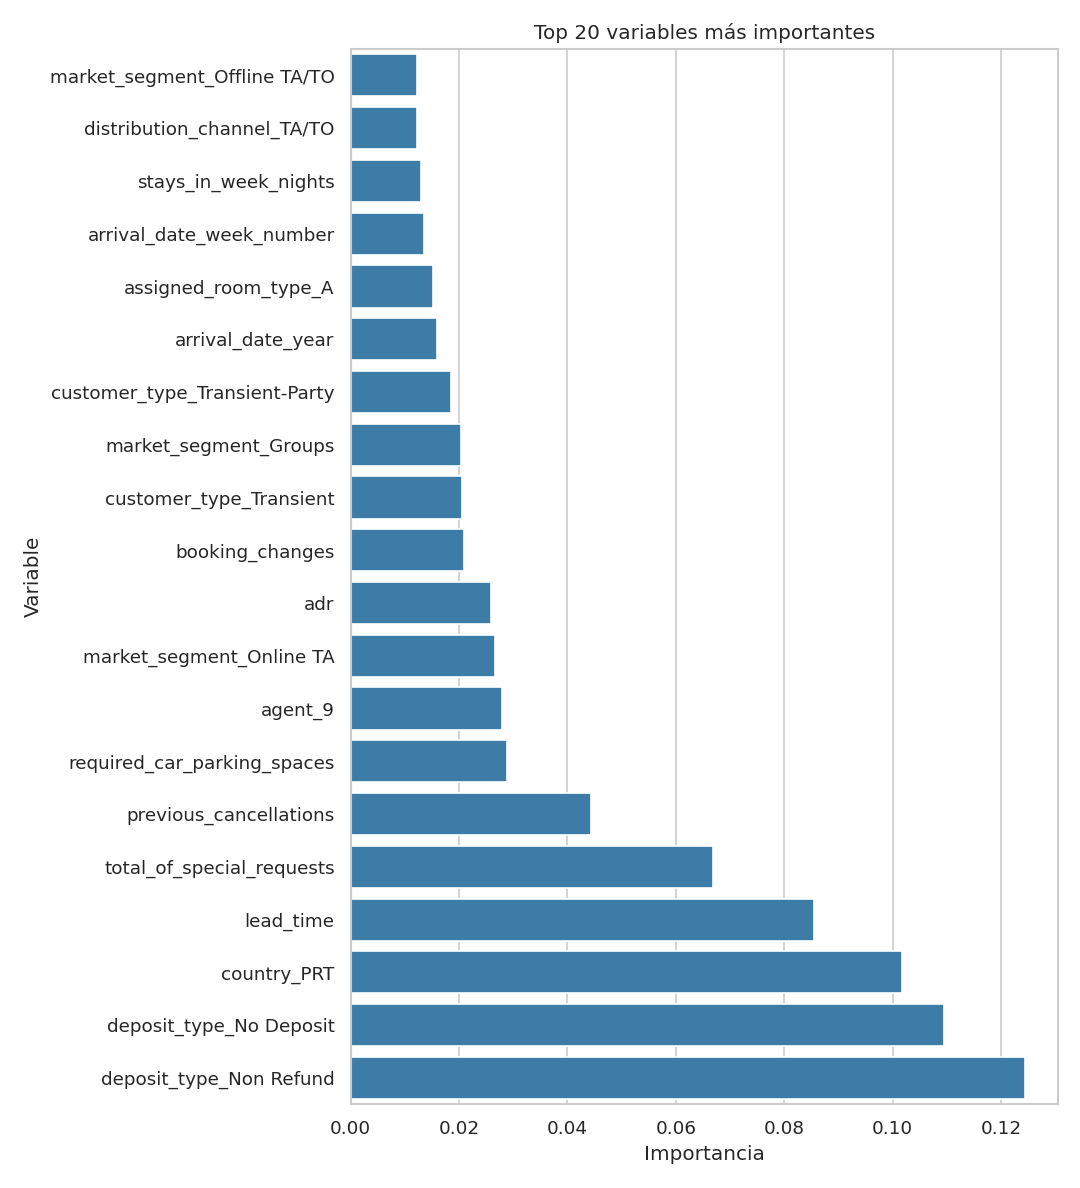

In [8]:
display(Image(filename=str(config.OUTPUTS_DIR / 'feature_importance.png')))

**Lectura.** Las variables más influyentes coinciden con lo que vimos en el EDA: `deposit_type=Non Refund` (depósito no reembolsable), `lead_time` (antelación), `adr` (precio), `country` (país) y `total_of_special_requests` (peticiones especiales) dominan la predicción. Que el modelo se apoye en variables que **tienen sentido** aumenta nuestra confianza en él.

## 6. Visualización 2D de los modelos

Queremos *ver* en un plano cómo se reparten las cancelaciones y **comparar los cinco modelos**. El obstáculo (visto en el EDA): de las variables numéricas solo `lead_time` y `adr` son realmente continuas, y la **señal que separa las cancelaciones es categórica** (`deposit_type`, `country`...). Por eso un simple *scatter* de dos variables continuas sale muy solapado.

Usamos dos técnicas **complementarias** para sortear ese problema:

- **6.1 Proyección PLS + regiones de decisión** — un mapa 2D donde las clases *sí* se separan, para comparar la frontera de cada modelo.
- **6.2 Mapa t-SNE** — un mapa no lineal que revela agrupaciones, coloreado por la predicción de cada modelo.

Todos los términos están en `docs/glosario.md`.

### 6.1 Proyección supervisada (PLS) + regiones de decisión

**El problema de PCA.** Para dibujar datos de muchas dimensiones en 2D hay que *proyectarlos*. PCA elige las 2 direcciones de **mayor varianza**, pero **ignora la clase**: si lo que separa las cancelaciones no coincide con lo que más varía, PCA las mezcla (nos pasó: las clases salían superpuestas).

**La solución: PLS.** *Partial Least Squares* hace lo mismo que PCA pero **mirando el `target`**: elige las 2 direcciones (componentes) más correlacionadas con `is_canceled`. El resultado es un mapa 2D donde las clases **sí se separan**: un clasificador lineal sobre solo estas 2 componentes logra un ROC-AUC ≈ 0.88 (con las ~200 variables originales sería ≈ 0.91). La **componente 1** se comporta como un *índice de riesgo de cancelación*.

**Cómo se construye el gráfico:**
1. Proyectamos todas las reservas al plano PLS (2 ejes).
2. **Reentrenamos los 5 modelos** sobre esas 2 componentes. (No se pueden dibujar en 2D los modelos originales, que usan ~200 columnas; aquí cada uno aprende de nuevo con solo 2 variables. La red neuronal real de Keras se sustituye por un `MLPClassifier` equivalente de scikit-learn, más ligero.)
3. Evaluamos la probabilidad de cada modelo en **toda** la rejilla del plano y la pintamos: **rojo** = predice cancelación, **azul** = no; la **línea negra** es la frontera 0.5. Los puntos son reservas reales de *test* coloreadas por su clase verdadera (para contrastarlas con el fondo).

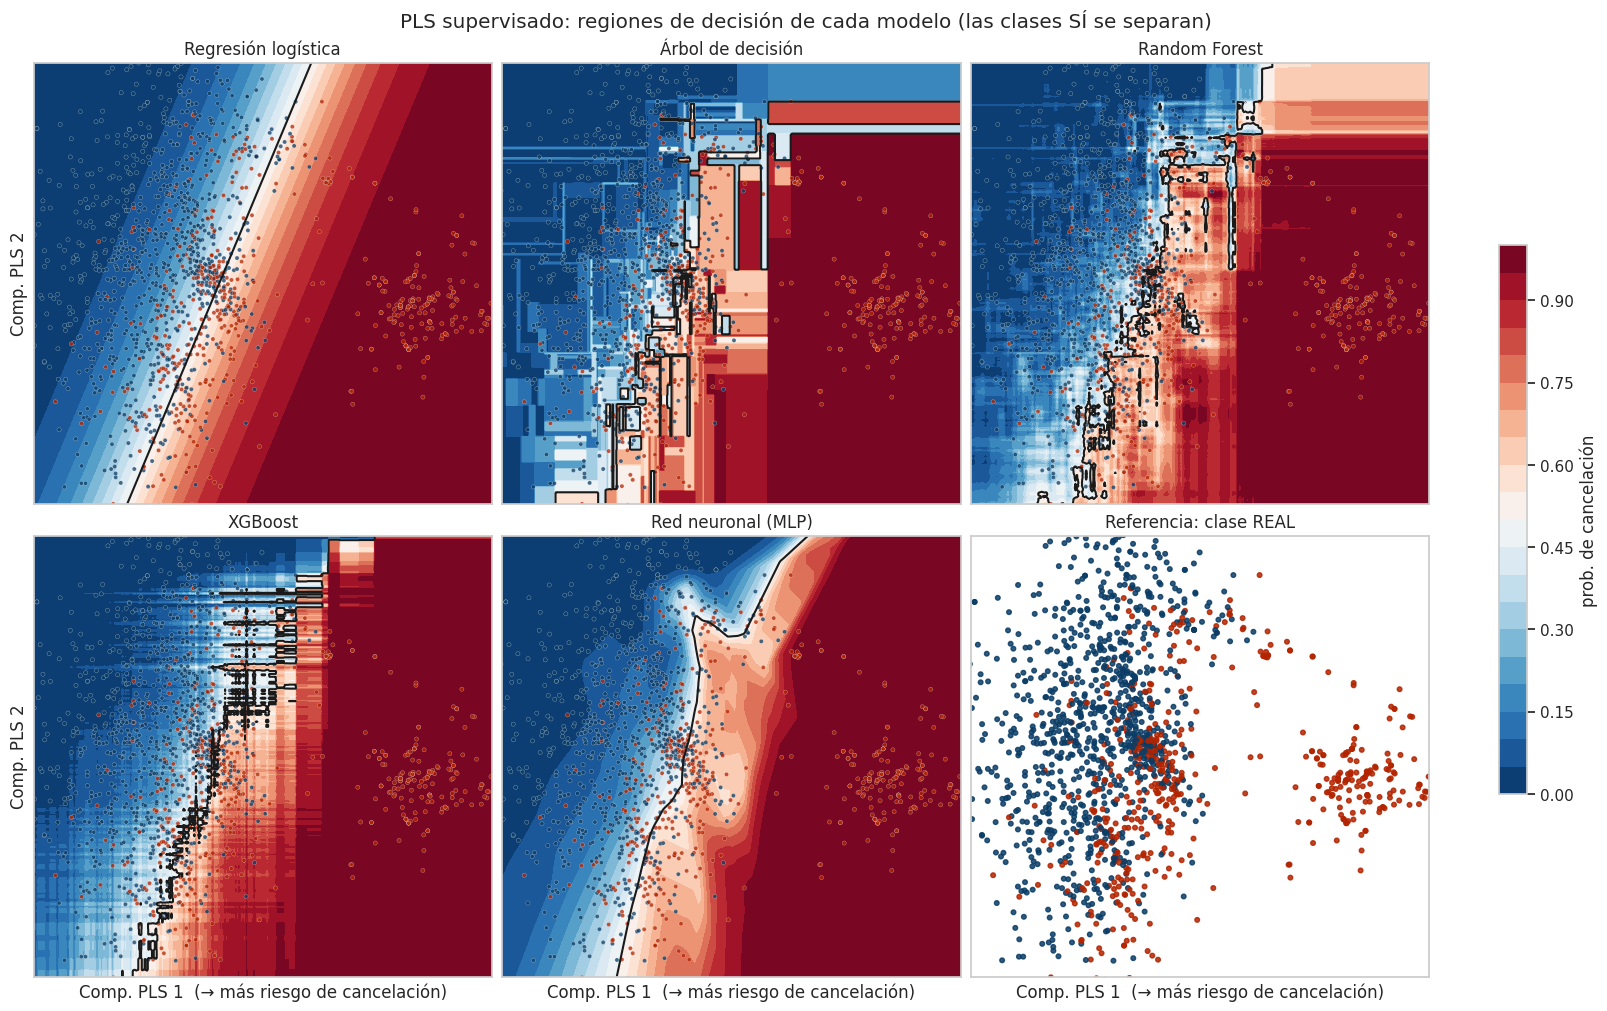

In [9]:
%matplotlib inline
# src.evaluator fija el backend 'Agg' al importarse; reactivamos el interactivo.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from src.preprocessing import build_preprocessor

# Preprocesador común (idéntico para todos: misma semilla y datos)
prep = build_preprocessor().fit(X_train)
Ztr, Zte = prep.transform(X_train), prep.transform(X_test)

# PLS supervisado a 2 componentes; orientamos el eje 1 hacia 'más riesgo'.
pls = PLSRegression(n_components=2).fit(Ztr, y_train.values)
Ctr, Cte = pls.transform(Ztr), pls.transform(Zte)
if Ctr[y_train.values == 1, 0].mean() < Ctr[y_train.values == 0, 0].mean():
    Ctr[:, 0] *= -1; Cte[:, 0] *= -1

modelos_2d = {
    'Regresión logística': LogisticRegression(max_iter=1000, random_state=config.RANDOM_STATE),
    'Árbol de decisión': DecisionTreeClassifier(**config.DECISION_TREE_PARAMS),
    'Random Forest': RandomForestClassifier(**config.RANDOM_FOREST_PARAMS),
    'XGBoost': XGBClassifier(**config.XGBOOST_PARAMS),
    'Red neuronal (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400,
                                        random_state=config.RANDOM_STATE),
}
for m in modelos_2d.values():
    m.fit(Ctr, y_train.values)

x0, x1 = np.percentile(Ctr[:, 0], [1, 99]); y0, y1 = np.percentile(Ctr[:, 1], [1, 99])
xx, yy = np.meshgrid(np.linspace(x0, x1, 300), np.linspace(y0, y1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
idx = np.random.RandomState(config.RANDOM_STATE).choice(len(Cte), 1500, replace=False)
cmap_pts = ListedColormap(['#0b3d66', '#b32400'])

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel(); cf = None
for ax, (nombre, m) in zip(axes, modelos_2d.items()):
    Zp = m.predict_proba(grid)[:, 1].reshape(xx.shape)
    cf = ax.contourf(xx, yy, Zp, levels=np.linspace(0, 1, 21), cmap='RdBu_r', vmin=0, vmax=1)
    ax.contour(xx, yy, Zp, levels=[0.5], colors='k', linewidths=1.5)
    ax.scatter(Cte[idx, 0], Cte[idx, 1], c=y_test.values[idx], cmap=cmap_pts,
               s=9, edgecolor='white', linewidth=0.2, alpha=0.75)
    ax.set_title(nombre); ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_xticks([]); ax.set_yticks([])
axes[5].scatter(Cte[idx, 0], Cte[idx, 1], c=y_test.values[idx], cmap=cmap_pts, s=11, alpha=0.85)
axes[5].set_title('Referencia: clase REAL')
axes[5].set_xlim(x0, x1); axes[5].set_ylim(y0, y1); axes[5].set_xticks([]); axes[5].set_yticks([])
for k, ax in enumerate(axes):
    if k // 3 == 1: ax.set_xlabel('Comp. PLS 1  (→ más riesgo de cancelación)')
    if k % 3 == 0: ax.set_ylabel('Comp. PLS 2')
fig.colorbar(cf, ax=axes.tolist(), shrink=0.6, label='prob. de cancelación')
fig.suptitle('PLS supervisado: regiones de decisión de cada modelo (las clases SÍ se separan)')
plt.show()

**Lectura.** La separación es clara: **azul (no cancela) a la izquierda, rojo (cancela) a la derecha**, siguiendo el eje de riesgo (compáralo con el panel "Referencia"). Se aprecia la personalidad de cada modelo —logística recta, árbol en bloques, Random Forest más limpio, XGBoost fragmentado, MLP suave—, pero **todos separan bien**, porque las 2 componentes PLS ya concentran casi toda la señal (incluida la de las variables categóricas).

### 6.2 Mapa no lineal (t-SNE)

**Qué es.** *t-SNE* (*t-distributed Stochastic Neighbor Embedding*) es otra forma de llevar las ~200 variables a 2D, pero **no lineal**: en vez de buscar direcciones rectas, intenta que los puntos **vecinos en el espacio original sigan siendo vecinos** en el mapa. Es ideal para descubrir **agrupaciones** (grumos) que PCA/PLS no captan.

**Cómo se lee.** Al contrario que en PLS, en t-SNE **los ejes y las distancias grandes NO significan nada**: solo importa qué puntos quedan *juntos*. El parámetro `perplexity` (aquí 30) regula el tamaño del vecindario que tiene en cuenta. Por su coste de cálculo lo aplicamos a una **muestra de 2 000 reservas**.

**Qué dibujamos.** El **mismo mapa** seis veces: el primer panel colorea por la **clase real**; los otros cinco, por la **probabilidad que asigna cada modelo REAL** (los entrenados en `python -m src.train`, esta vez **sin reentrenar**). Donde el color de un modelo coincide con el del panel "Clase REAL", ese modelo está acertando.

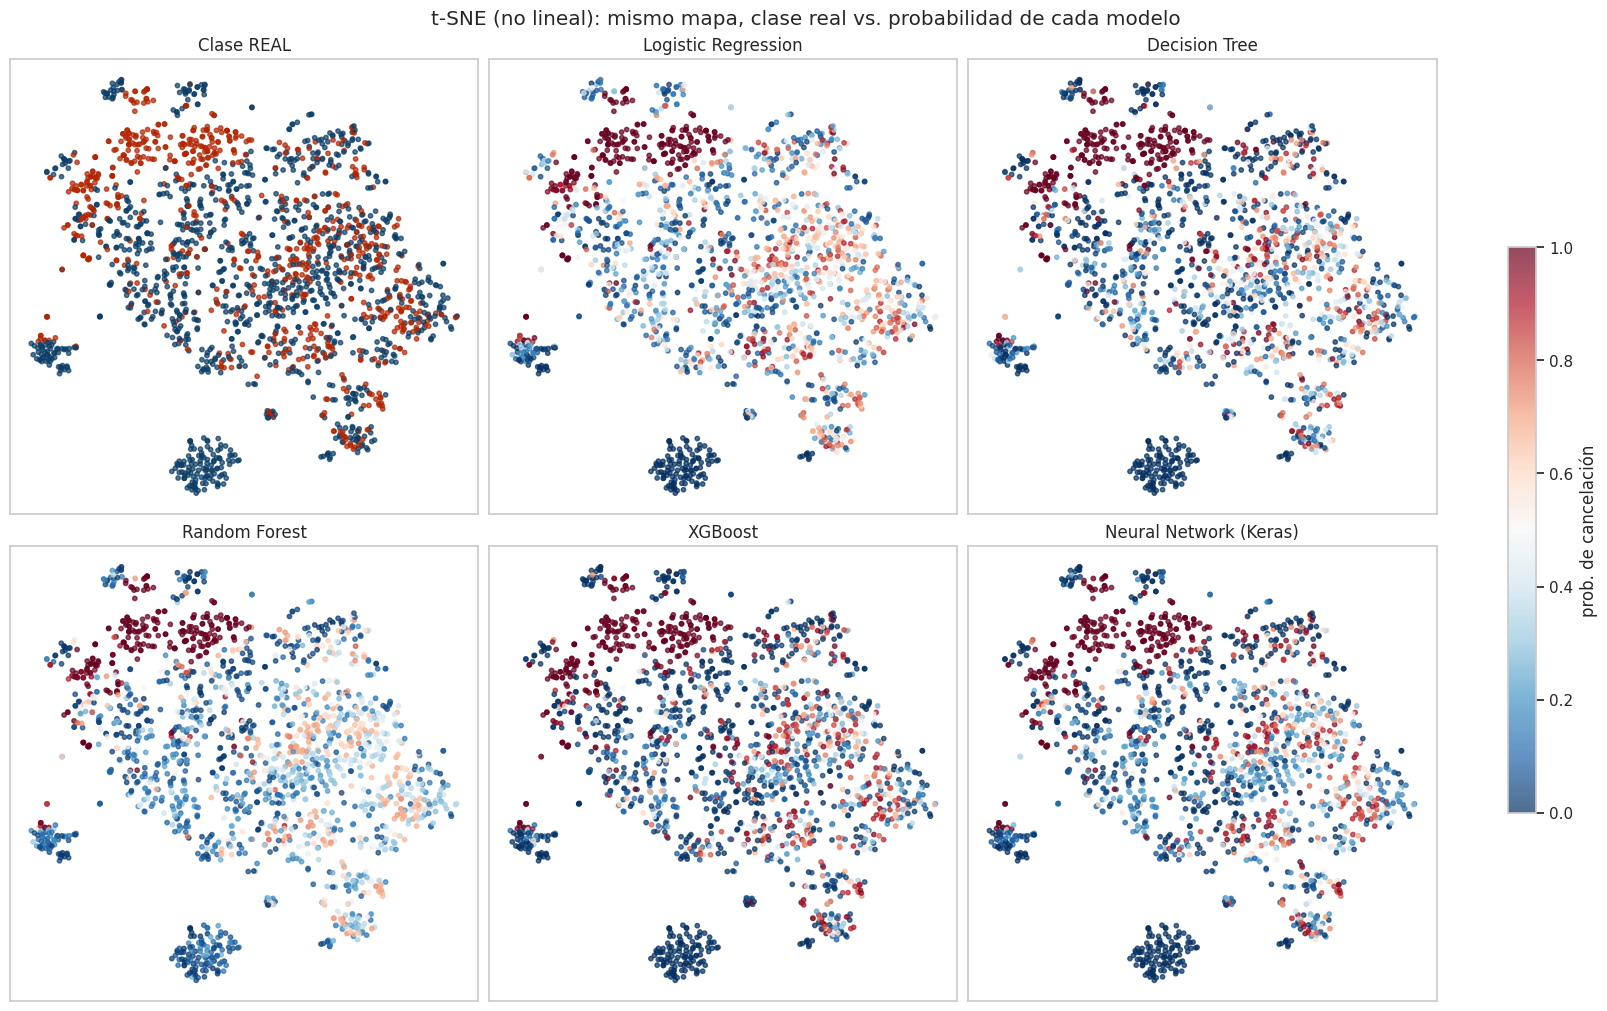

In [10]:
from sklearn.manifold import TSNE

mt = X_test.sample(2000, random_state=config.RANDOM_STATE); yt = y_test.loc[mt.index]
coords = TSNE(n_components=2, random_state=config.RANDOM_STATE,
              perplexity=30, init='pca').fit_transform(prep.transform(mt))

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel(); sc = None
axes[0].scatter(coords[:, 0], coords[:, 1], c=yt.values, cmap=cmap_pts, s=10, alpha=0.7)
axes[0].set_title('Clase REAL')
for ax, (nombre, m) in zip(axes[1:], modelos.items()):
    pr = m.predict_proba(mt)[:, 1]
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=pr, cmap='RdBu_r', s=10, alpha=0.7, vmin=0, vmax=1)
    ax.set_title(nombre)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=axes.tolist(), shrink=0.6, label='prob. de cancelación')
fig.suptitle('t-SNE (no lineal): mismo mapa, clase real vs. probabilidad de cada modelo')
plt.show()

**Lectura.** Aparecen "grumos" donde se concentran las cancelaciones (rojo). Los cinco modelos reproducen ese patrón de forma muy parecida al panel real, lo que confirma que **coinciden en gran medida**; las diferencias finas entre ellos (las que decide el ROC-AUC) no se aprecian a simple vista.

## 7. Inferencia: usar el mejor modelo para predecir

**Inferencia** = usar un modelo ya entrenado sobre datos nuevos. Cargamos `best_model.pkl` y predecimos sobre una muestra. El modelo devuelve una **probabilidad** de cancelación (entre 0 y 1) y la decisión 0/1 aplicando el umbral 0.5.

In [11]:
from src.predict import load_best_model, predict_dataframe
from src.data_loader import load_raw_data

best = load_best_model()
muestra = load_raw_data().sample(8, random_state=config.RANDOM_STATE)
predict_dataframe(muestra, model=best)

,prediction,probability_canceled
30946,0,0.0368
40207,1,0.9743
103708,0,0.0004
85144,0,0.0229
109991,1,0.6576
110622,1,0.7417
47790,1,0.7722
44992,0,0.0002


## 8. Conclusión

**XGBoost** es el mejor modelo según ROC-AUC, seguido de cerca por la red neuronal y el Random Forest. Es el que se guarda como `models/best_model.pkl` para hacer predicciones. Los detalles, limitaciones y líneas de mejora están en `docs/informe_final.md`, y todos los términos en `docs/glosario.md`.